# Фінальний проєкт. Частина 4: донавчання енкодерів замість заморожених

Основний пайплайн (ноутбуки 02 і 03) тримає енкодери замороженими і вчить поверх векторів лінійні моделі та бустинг.
Тут перевіряю альтернативу з програми курсу: навчити або донавчити моделі end-to-end, CNN і ResNet-50 на фото,
BiLSTM і DistilBERT на тексті. Усе на одному фолді (фолд 0 з ноутбука 03), планка для порівняння це заморожені
CLIP + SigLIP2 + Ridge на тому самому фолді. На Apple M4 Pro весь ноутбук іде близько 11 хвилин.

In [1]:
import random
import re
import time
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from sklearn.linear_model import RidgeCV
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import StratifiedKFold
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import models
from torchvision.transforms import v2
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
from transformers import logging as hf_logging
from tqdm.auto import tqdm

hf_logging.set_verbosity_error()
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
NUM_WORKERS = 4 if device.type == "cuda" else 0   # на macOS воркери DataLoader з ноутбука не стартують
print(device)

EMB_DIR = Path("Results/embeddings")
RES_DIR = Path("Results")
FIG_DIR = RES_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
assert (EMB_DIR / "pet_siglip2_mean.npy").exists(), "спочатку треба виконати 02_Embeddings_Parshyn.ipynb"

mps


## Дані і фолд

Той самий поділ, що в ноутбуці 03: StratifiedKFold на 5 фолдів з seed 42, беру фолд 0. Усі моделі вчаться на його
train-частині і оцінюються на val-частині, test тут не потрібен. З фото беру тільки перше, його бачить відвідувач у списку.

In [2]:
pets = pd.read_csv(EMB_DIR / "pets.csv", dtype={"PetID": str})
photos = pd.read_csv(EMB_DIR / "photos.csv", dtype={"PetID": str})
pets["Description"] = pets.Description.fillna("")

if not Path(photos.path.iloc[0]).exists():
    # кеш ембеддингів перенесли з іншої машини: шляхи до фото перебудовую так само, як у ноутбуці 02
    DATA_DIR = Path("Data")
    if not (DATA_DIR / "train.csv").exists():
        import kagglehub
        DATA_DIR = Path(kagglehub.competition_download("deep-learning-for-computer-vision-and-nlp-2026-10"))
    IMG_DIRS = {s: next(p for p in DATA_DIR.rglob(s) if p.is_dir() and any(p.glob("*.jpg"))) for s in ("train", "test")}
    photos["path"] = [str(IMG_DIRS[s] / Path(p).name) for s, p in zip(photos.split, photos.path)]

is_train = (pets.split == "train").values
tr_idx = np.flatnonzero(is_train)
y = pets.AdoptionSpeed.values[tr_idx].astype(int)

folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(tr_idx, y))
tr, va = folds[0]                       # позиції в межах tr_idx
y_tr, y_va = y[tr], y[va]
texts_tr = pets.Description.values[tr_idx[tr]]
texts_va = pets.Description.values[tr_idx[va]]
first_photo = photos.drop_duplicates("PetID").set_index("PetID").path   # photos відсортовано за photo_no, перший рядок це фото 1
paths_tr = first_photo[pets.PetID.values[tr_idx[tr]]].tolist()
paths_va = first_photo[pets.PetID.values[tr_idx[va]]].tolist()
print("train:", len(tr), " val:", len(va))
print("класи train:", np.bincount(y_tr)[1:], " val:", np.bincount(y_va)[1:])

train: 5144  val: 1287
класи train: [ 958 1418 1062 1706]  val: [239 355 266 427]


## Оцінка

Кожна модель видає число, класи ріжу порогами. Пороги це квантилі прогнозів на val при накопичених частотах класів
train: розподіл передбачених класів підганяється під train, мітки val у підборі не беруть участі. Простіше за
Nelder-Mead з ноутбука 03, зате на одному фолді нічого не переоцінює. У таблицю йде QWK останньої епохи, найкращу
епоху за val не вибираю.

In [3]:
def qwk_with_matched_thresholds(score_val, y_train, y_val):
    cum = np.cumsum(np.bincount(y_train, minlength=5)[1:4]) / len(y_train)
    thr = np.quantile(score_val, cum)
    pred = 1 + np.searchsorted(thr, score_val, side="right")
    return cohen_kappa_score(y_val, pred, weights="quadratic")


results = []


def add_result(name, modality, params, epochs, seconds, score_val):
    q = qwk_with_matched_thresholds(score_val, y_tr, y_va)
    results.append(dict(model=name, modality=modality, params=params, epochs=epochs,
                        train_time_s=round(seconds), val_qwk=round(q, 4)))
    print(f"{name}: val QWK = {q:.4f}  ({seconds:.0f} с)")
    return q


def n_params(model):
    return sum(p.numel() for p in model.parameters())


def free_memory():
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()

## Спільний цикл навчання

Усі нейромережі регресують номер класу з MSE: QWK карає за квадрат відстані між класами, тому одне число з порогами
природніше за 4 логіти. Батч це кортеж (входи..., ціль), тому один цикл підходить і для фото, і для тексту.

In [4]:
criterion = nn.MSELoss()


def predict(model, loader):
    model.eval()
    out = []
    with torch.no_grad():
        for *inputs, _ in loader:
            out.append(model(*[t.to(device) for t in inputs]).float().cpu())
    return torch.cat(out).numpy()


def fit(model, train_loader, val_loader, optimizer, epochs, scheduler=None):
    history, t0 = [], time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        total, n_seen = torch.zeros((), device=device), 0
        for *inputs, target in train_loader:
            inputs = [t.to(device) for t in inputs]
            target = target.to(device)
            optimizer.zero_grad()
            loss = criterion(model(*inputs), target)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
            total += loss.detach() * len(target)
            n_seen += len(target)
        score_va = predict(model, val_loader)
        q = qwk_with_matched_thresholds(score_va, y_tr, y_va)
        history.append((total.item() / n_seen, q))
        print(f"  епоха {epoch}: train MSE {history[-1][0]:.4f}  val QWK {q:.4f}  ({time.time() - t0:.0f} с)")
    return np.array(history), score_va, time.time() - t0

## Референс: заморожені CLIP + SigLIP2 + Ridge

Та сама пара енкодерів, що в основному пайплайні, і найпростіша модель поверх них. Усе, що нижче, має побити це число.

In [5]:
t0 = time.time()
X = np.hstack([np.load(EMB_DIR / "pet_clip_mean.npy"), np.load(EMB_DIR / "pet_siglip2_mean.npy")]).astype(np.float32)
X_tr, X_va = X[tr_idx[tr]], X[tr_idx[va]]
print("X:", X_tr.shape, X_va.shape)
ridge = RidgeCV(alphas=np.logspace(-1, 4, 11)).fit(X_tr, y_tr)
print(f"alpha = {ridge.alpha_:g}")
qwk_ref = add_result("CLIP + SigLIP2 заморожені + Ridge", "фото", ridge.coef_.size, "-", time.time() - t0, ridge.predict(X_va))

X: (5144, 1920) (1287, 1920)


alpha = 3.16228
CLIP + SigLIP2 заморожені + Ridge: val QWK = 0.5795  (1 с)


## Кеш фото

Перше фото кожної тварини фолду декодую один раз: коротша сторона до 256, центральний кроп 256x256, uint8.
Аугментації далі працюють на тензорах, тому епоха не впирається в читання JPEG.

In [6]:
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
CACHE_SIZE = 256


def load_square(path):
    img = v2.functional.pil_to_tensor(Image.open(path).convert("RGB"))
    return v2.functional.center_crop(v2.functional.resize(img, CACHE_SIZE, antialias=True), CACHE_SIZE)


def build_cache(paths):
    with ThreadPoolExecutor(8) as pool:
        return torch.stack(list(tqdm(pool.map(load_square, paths), total=len(paths), mininterval=10)))


t0 = time.time()
imgs_tr, imgs_va = build_cache(paths_tr), build_cache(paths_va)
print(tuple(imgs_tr.shape), tuple(imgs_va.shape), imgs_tr.dtype, f"{(imgs_tr.nbytes + imgs_va.nbytes) / 2**30:.2f} GB, {time.time() - t0:.0f} с")


class CachedImages(Dataset):
    def __init__(self, imgs, targets, transform):
        self.imgs, self.transform = imgs, transform
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        return self.transform(self.imgs[i]), self.targets[i]


def image_transforms(size):
    to_float = [v2.ToDtype(torch.float32, scale=True), v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    train_tf = v2.Compose([v2.RandomResizedCrop(size, scale=(0.7, 1.0), antialias=True), v2.RandomHorizontalFlip(), *to_float])
    eval_tf = v2.Compose([v2.Resize(round(size / 0.875), antialias=True), v2.CenterCrop(size), *to_float])   # для 224 це Resize(256) + CenterCrop(224)
    return train_tf, eval_tf


def image_loaders(size, batch_size):
    train_tf, eval_tf = image_transforms(size)
    train_loader = DataLoader(CachedImages(imgs_tr, y_tr, train_tf), batch_size=batch_size, shuffle=True, drop_last=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(CachedImages(imgs_va, y_va, eval_tf), batch_size=2 * batch_size, num_workers=NUM_WORKERS)
    return train_loader, val_loader

  0%|          | 0/5144 [00:00<?, ?it/s]

  0%|          | 0/1287 [00:00<?, ?it/s]

(5144, 3, 256, 256) (1287, 3, 256, 256) torch.uint8 1.18 GB, 2 с


## CNN з нуля

Чотири блоки conv3x3 + BatchNorm + ReLU + MaxPool, глобальне усереднення, лінійний вихід. Фото 128x128, 8 епох, Adam.
Це нижня планка: що дає згорткова архітектура без жодного попереднього навчання на 5 тисячах фото.

In [7]:
class SmallCNN(nn.Module):
    def __init__(self, widths=(32, 64, 128, 256)):
        super().__init__()
        blocks, c_in = [], 3
        for c in widths:
            blocks += [nn.Conv2d(c_in, c, 3, padding=1, bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True), nn.MaxPool2d(2)]
            c_in = c
        self.features = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(c_in, 1), nn.Flatten(0))   # (B, 1) -> (B,)

    def forward(self, x):
        return self.head(self.features(x))


EPOCHS_CNN = 8
train_loader, val_loader = image_loaders(128, batch_size=64)
model = SmallCNN().to(device)
model.head[3].bias.data.fill_(y_tr.mean())   # старт із середнього класу, перші епохи не йдуть на підбір зсуву
x, _ = next(iter(train_loader))
model.eval()
with torch.no_grad():
    print("вхід", tuple(x.shape), "-> вихід", tuple(model(x.to(device)).shape), f" параметрів: {n_params(model):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
hist_cnn, score_cnn, sec = fit(model, train_loader, val_loader, optimizer, EPOCHS_CNN)
add_result("CNN з нуля, 128px", "фото", n_params(model), EPOCHS_CNN, sec, score_cnn)
del model
free_memory()

вхід (64, 3, 128, 128) -> вихід (64,)  параметрів: 389,153


  епоха 1: train MSE 1.3572  val QWK 0.0482  (5 с)


  епоха 2: train MSE 1.2690  val QWK 0.1102  (9 с)


  епоха 3: train MSE 1.2633  val QWK 0.1239  (14 с)


  епоха 4: train MSE 1.2519  val QWK 0.1599  (18 с)


  епоха 5: train MSE 1.2430  val QWK 0.1388  (23 с)


  епоха 6: train MSE 1.2280  val QWK 0.1487  (27 с)


  епоха 7: train MSE 1.2290  val QWK 0.1748  (31 с)


  епоха 8: train MSE 1.2298  val QWK 0.1171  (36 с)
CNN з нуля, 128px: val QWK = 0.1171  (36 с)


## ResNet-50: заморожений проти донавченого

Спершу той самий бекбон як заморожений екстрактор: 2048 ознак з передостаннього шару на центральному кропі 224 і Ridge
поверх, рівно як з CLIP у референсі. Далі його ж донавчаю повністю, щоб різниця була видна на одному бекбоні.

In [8]:
@torch.no_grad()
def extract_features(model, imgs, transform):
    model.eval()
    loader = DataLoader(CachedImages(imgs, np.zeros(len(imgs)), transform), batch_size=64, num_workers=NUM_WORKERS)
    return torch.cat([model(x.to(device)).float().cpu() for x, _ in loader]).numpy()


t0 = time.time()
_, eval_tf = image_transforms(224)
backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
backbone.fc = nn.Identity()
backbone = backbone.to(device)
feats_tr, feats_va = extract_features(backbone, imgs_tr, eval_tf), extract_features(backbone, imgs_va, eval_tf)
print("ознаки:", feats_tr.shape, feats_va.shape, f"({time.time() - t0:.0f} с на витяг)")
ridge = RidgeCV(alphas=np.logspace(-1, 4, 11)).fit(feats_tr, y_tr)
print(f"alpha = {ridge.alpha_:g}")
add_result("ResNet-50 заморожений + Ridge", "фото", ridge.coef_.size, "-", time.time() - t0, ridge.predict(feats_va))
del backbone
free_memory()

ознаки: (5144, 2048) (1287, 2048) (21 с на витяг)


alpha = 316.228
ResNet-50 заморожений + Ridge: val QWK = 0.4479  (22 с)


## ResNet-50 донавчання end-to-end

Голова це один лінійний вихід. Бекбон вчиться з lr 1e-4, голова з 1e-3, AdamW, косинусний спад lr, 4 епохи, батч 32,
аугментації RandomResizedCrop(0.7..1) і горизонтальний фліп. Усі 25M параметрів розморожені.

In [9]:
EPOCHS_RN = 4
train_loader, val_loader = image_loaders(224, batch_size=32)
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(model.fc.in_features, 1), nn.Flatten(0))
model.fc[1].bias.data.fill_(y_tr.mean())
model = model.to(device)
head_params = list(model.fc.parameters())
backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
print(f"параметрів: {n_params(model):,}, з них у голові {sum(p.numel() for p in head_params):,}")

optimizer = torch.optim.AdamW([{"params": backbone_params, "lr": 1e-4}, {"params": head_params, "lr": 1e-3}], weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_RN * len(train_loader))
hist_rn, score_rn, sec = fit(model, train_loader, val_loader, optimizer, EPOCHS_RN, scheduler)
add_result("ResNet-50 донавчений, 224px", "фото", n_params(model), EPOCHS_RN, sec, score_rn)
del model, optimizer
free_memory()

параметрів: 23,510,081, з них у голові 2,049


  епоха 1: train MSE 1.0212  val QWK 0.4380  (67 с)


  епоха 2: train MSE 0.7451  val QWK 0.4373  (134 с)


  епоха 3: train MSE 0.5360  val QWK 0.4330  (202 с)


  епоха 4: train MSE 0.4281  val QWK 0.4367  (271 с)
ResNet-50 донавчений, 224px: val QWK = 0.4367  (271 с)


## BiLSTM на тексті з нуля

Токенізація регуляркою, словник зі слів train-частини з частотою від 2, ембеддинги 128 вчаться з нуля, один шар
BiLSTM на 128 у кожен бік, mean і max pooling по часу, лінійний вихід. До 200 токенів на опис, 6 епох.

In [10]:
MAX_TOKENS, MIN_FREQ = 200, 2
tokenize = lambda s: re.findall(r"[a-z0-9]+(?:'[a-z]+)?", s.lower())

counter = Counter(tok for s in texts_tr for tok in tokenize(s))
vocab = {"<pad>": 0, "<unk>": 1}
for tok, c in counter.most_common():
    if c < MIN_FREQ:
        break
    vocab[tok] = len(vocab)
print(f"різних слів у train: {len(counter):,}, у словнику: {len(vocab):,}")


class TextDataset(Dataset):
    def __init__(self, texts, targets):
        self.ids = [torch.tensor([vocab.get(t, 1) for t in tokenize(s)][:MAX_TOKENS] or [0]) for s in texts]   # порожній опис = один <pad>
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        return self.ids[i], self.targets[i]


def collate_text(batch):
    ids, targets = zip(*batch)
    lengths = torch.tensor([len(x) for x in ids])
    return pad_sequence(ids, batch_first=True), lengths, torch.stack(targets)


class BiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden=128):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(4 * hidden, 1), nn.Flatten(0))

    def forward(self, ids, lengths):
        packed = pack_padded_sequence(self.emb(ids), lengths.cpu(), batch_first=True, enforce_sorted=False)   # довжини для pack лише на CPU
        out, _ = pad_packed_sequence(self.lstm(packed)[0], batch_first=True)
        mask = (torch.arange(out.shape[1], device=out.device)[None] < lengths[:, None])[..., None]
        mean = (out * mask).sum(1) / mask.sum(1)
        mx = out.masked_fill(~mask, float("-inf")).max(1).values
        return self.head(torch.cat([mean, mx], 1))


EPOCHS_LSTM = 6
train_loader = DataLoader(TextDataset(texts_tr, y_tr), batch_size=64, shuffle=True, collate_fn=collate_text, num_workers=NUM_WORKERS)
val_loader = DataLoader(TextDataset(texts_va, y_va), batch_size=128, collate_fn=collate_text, num_workers=NUM_WORKERS)
model = BiLSTM(len(vocab)).to(device)
model.head[1].bias.data.fill_(y_tr.mean())
ids, lengths, _ = next(iter(train_loader))
print("батч", tuple(ids.shape), "довжини від", lengths.min().item(), "до", lengths.max().item(), f" параметрів: {n_params(model):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
hist_lstm, score_lstm, sec = fit(model, train_loader, val_loader, optimizer, EPOCHS_LSTM)
add_result("BiLSTM з нуля", "текст", n_params(model), EPOCHS_LSTM, sec, score_lstm)
del model
free_memory()

різних слів у train: 12,419, у словнику: 7,182


батч (64, 200) довжини від 1 до 200  параметрів: 1,184,001


  епоха 1: train MSE 1.2155  val QWK 0.2331  (21 с)


  епоха 2: train MSE 1.1040  val QWK 0.2722  (41 с)


  епоха 3: train MSE 0.9853  val QWK 0.2909  (61 с)


  епоха 4: train MSE 0.8651  val QWK 0.2952  (82 с)


  епоха 5: train MSE 0.7390  val QWK 0.2890  (102 с)


  епоха 6: train MSE 0.6191  val QWK 0.2859  (122 с)
BiLSTM з нуля: val QWK = 0.2859  (122 с)


## DistilBERT донавчання

`distilbert-base-uncased` з регресійною головою на 1 вихід (її ваги нові, решта з претрену), 128 токенів, батч 32,
lr 3e-5, AdamW з лінійним розігрівом і спадом, 3 епохи. Це 66M параметрів проти 2M у BiLSTM, але головне тут не розмір,
а попереднє навчання на тексті.

In [11]:
MODEL_NAME, MAX_LEN = "distilbert-base-uncased", 128
EPOCHS_BERT = 3
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tensor_dataset(texts, targets):
    enc = tokenizer(list(texts), padding="max_length", truncation=True, max_length=MAX_LEN, return_tensors="pt")   # фіксована довжина, однакові форми батчів
    return TensorDataset(enc["input_ids"], enc["attention_mask"], torch.tensor(targets, dtype=torch.float32))


class BertRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1, problem_type="regression")

    def forward(self, input_ids, attention_mask):
        return self.bert(input_ids=input_ids, attention_mask=attention_mask).logits[:, 0]


ds_tr, ds_va = tensor_dataset(texts_tr, y_tr), tensor_dataset(texts_va, y_va)
print(f"input_ids {tuple(ds_tr.tensors[0].shape)}, упираються в {MAX_LEN} токенів: {(ds_tr.tensors[1].sum(1) == MAX_LEN).float().mean():.0%} описів train")
train_loader = DataLoader(ds_tr, batch_size=32, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(ds_va, batch_size=64, num_workers=NUM_WORKERS)
model = BertRegressor().to(device)
model.bert.classifier.bias.data.fill_(y_tr.mean())
print(f"параметрів: {n_params(model):,}")
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
steps = EPOCHS_BERT * len(train_loader)
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * steps), steps)
hist_bert, score_bert, sec = fit(model, train_loader, val_loader, optimizer, EPOCHS_BERT, scheduler)
add_result("DistilBERT донавчений", "текст", n_params(model), EPOCHS_BERT, sec, score_bert)
del model, optimizer
free_memory()

input_ids (5144, 128), упираються в 128 токенів: 21% описів train


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

параметрів: 66,954,241


  епоха 1: train MSE 1.2135  val QWK 0.2145  (67 с)


  епоха 2: train MSE 1.0321  val QWK 0.2753  (134 с)


  епоха 3: train MSE 0.8111  val QWK 0.3033  (201 с)
DistilBERT донавчений: val QWK = 0.3033  (201 с)


## Підсумок

Усі моделі на одному фолді з однаковою процедурою порогів. `params` це кількість параметрів, що навчалися: для Ridge
це коефіцієнти поверх замороженого енкодера.

                               model modality    params epochs  train_time_s  val_qwk
0  CLIP + SigLIP2 заморожені + Ridge     фото      1920      -             1   0.5795
1      ResNet-50 заморожений + Ridge     фото      2048      -            22   0.4479
2        ResNet-50 донавчений, 224px     фото  23510081      4           271   0.4367
3              DistilBERT донавчений    текст  66954241      3           201   0.3033
4                      BiLSTM з нуля    текст   1184001      6           122   0.2859
5                  CNN з нуля, 128px     фото    389153      8            36   0.1171


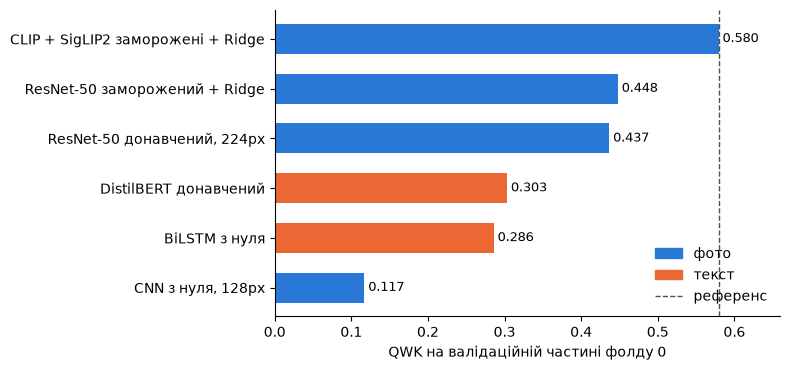

In [12]:
table = pd.DataFrame(results).sort_values("val_qwk", ascending=False).reset_index(drop=True)
table.to_csv(RES_DIR / "finetune_results.csv", index=False)
print(table.to_string())

COLORS = {"фото": "#2a78d6", "текст": "#eb6834"}
t = table.iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(t.model, t.val_qwk, color=[COLORS[m] for m in t.modality], height=0.6)
for b, v in zip(bars, t.val_qwk):
    ax.text(max(v, 0) + 0.005, b.get_y() + b.get_height() / 2, f"{v:.3f}", va="center", fontsize=9)
ref_line = ax.axvline(qwk_ref, color="#52514e", ls="--", lw=1)
ax.set_xlim(min(0, t.val_qwk.min() - 0.03), max(0.5, t.val_qwk.max() + 0.08))
ax.set_xlabel("QWK на валідаційній частині фолду 0")
ax.spines[["top", "right"]].set_visible(False)
ax.legend([*(plt.Rectangle((0, 0), 1, 1, color=c) for c in COLORS.values()), ref_line], [*COLORS.keys(), "референс"], frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "finetune_summary.png", dpi=120, bbox_inches="tight")
plt.show()

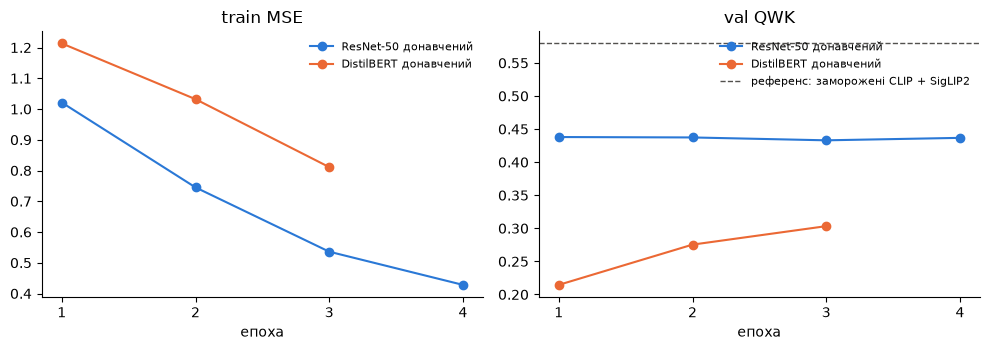

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for name, hist, color in [("ResNet-50 донавчений", hist_rn, COLORS["фото"]), ("DistilBERT донавчений", hist_bert, COLORS["текст"])]:
    ep = np.arange(1, len(hist) + 1)
    axes[0].plot(ep, hist[:, 0], "o-", color=color, label=name)
    axes[1].plot(ep, hist[:, 1], "o-", color=color, label=name)
axes[1].axhline(qwk_ref, color="#52514e", ls="--", lw=1, label="референс: заморожені CLIP + SigLIP2")
axes[0].set_title("train MSE")
axes[1].set_title("val QWK")
for ax in axes:
    ax.set_xlabel("епоха")
    ax.set_xticks(np.arange(1, max(len(hist_rn), len(hist_bert)) + 1))
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "finetune_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## Висновки

Попереднє навчання вирішує все: CNN з нуля на 5 тисячах фото дає QWK 0.12, той самий ResNet-50 з вагами ImageNet
як заморожений екстрактор 0.45, а заморожені CLIP + SigLIP2 з Ridge 0.58 на тому самому фолді. Донавчання ResNet-50
end-to-end за 4 епохи не додає нічого (0.44 проти 0.45 замороженого): train MSE падає з 1.02 до 0.43, а val QWK
стоїть на місці, тобто мережа запам'ятовує 5 тисяч фото замість того, щоб узагальнювати.

Текстові моделі помітно слабші за будь-які моделі на фото: BiLSTM з нуля 0.29, донавчений DistilBERT 0.30 за 3 епохи.
Це узгоджується з ноутбуком 03, де текстові ембеддинги з Ridge дають 0.30-0.34 проти 0.59 у фото.

Висновок для пайплайну: заморожені контрастивні енкодери, навчені на сотнях мільйонів пар фото-текст, і проста модель
поверх них виграють у донавчання на малому датасеті з великим відривом і за хвилину замість десятків. Тому основне
рішення в ноутбуці 03 тримає енкодери замороженими і вкладає зусилля в ознаки сусідів і стекінг.